Exercise 2: Binary Cross-Entropy Loss for ONE example (the ML angle)

Goal: Bridge from "cross-entropy of two distributions" to "loss function for a binary classifier."

Imagine a model predicts whether an email is spam. For ONE email:

True label: y (either 0 = not spam, or 1 = spam)
Model's prediction: p (a probability between 0 and 1)

The loss for this single email is:
loss = -(y * log(p) + (1-y) * log(1-p))

Your task
Implement binary_cross_entropy_single(y, p)
Compute loss for these test cases:

pythontest_cases = [
    (1, 0.99),   # True spam, model says 99% spam → tiny loss expected
    (1, 0.50),   # True spam, model says 50% spam → medium loss
    (1, 0.10),   # True spam, model says 10% spam → big loss (confidently wrong)
    (1, 0.01),   # True spam, model says 1% spam → HUGE loss (very confidently wrong)
    (0, 0.01),   # Not spam, model says 1% spam → tiny loss
    (0, 0.50),   # Not spam, model says 50% spam → medium loss
    (0, 0.99),   # Not spam, model says 99% spam → HUGE loss (very wrong)
]

Plot the loss curves for both cases (y=1 and y=0) as p varies from 0 to 1.

In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
def binary_cross_entropy_single(y, p):

    loss = -(y * np.log2(p) + (1-y) * np.log2(1-p))
    return loss

In [28]:
test_cases = [
    (1, 0.99),   # True spam, model says 99% spam → tiny loss expected
    (1, 0.50),   # True spam, model says 50% spam → medium loss
    (1, 0.10),   # True spam, model says 10% spam → big loss (confidently wrong)
    (1, 0.01),   # True spam, model says 1% spam → HUGE loss (very confidently wrong)
    (0, 0.01),   # Not spam, model says 1% spam → tiny loss
    (0, 0.50),   # Not spam, model says 50% spam → medium loss
    (0, 0.99),   # Not spam, model says 99% spam → HUGE loss (very wrong)
]

In [29]:
print("Single-example losses:\n")
for case in test_cases:
    y = case[0]
    p = case[1]
    bce = binary_cross_entropy_single(y,p)
    print(f" Y = {y}, P = {p}, Binary Cross-entropy = {bce}")

Single-example losses:

 Y = 1, P = 0.99, Binary Cross-entropy = 0.014499569695115089
 Y = 1, P = 0.5, Binary Cross-entropy = 1.0
 Y = 1, P = 0.1, Binary Cross-entropy = 3.321928094887362
 Y = 1, P = 0.01, Binary Cross-entropy = 6.643856189774724
 Y = 0, P = 0.01, Binary Cross-entropy = 0.014499569695115089
 Y = 0, P = 0.5, Binary Cross-entropy = 1.0
 Y = 0, P = 0.99, Binary Cross-entropy = 6.6438561897747235


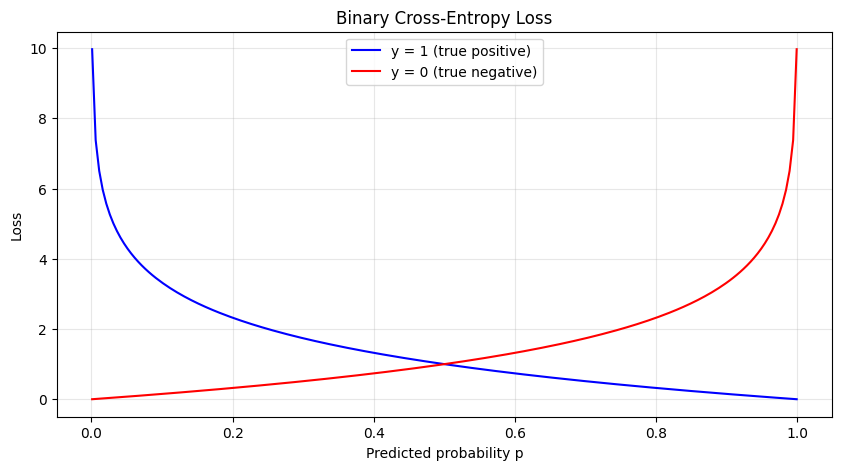

In [31]:
p_values = np.linspace(0.001, 0.999, 200)

loss_when_y_is_1 = [binary_cross_entropy_single(1, p) for p in p_values]
loss_when_y_is_0 = [binary_cross_entropy_single(0, p) for p in p_values]

plt.figure(figsize=(10, 5))
plt.plot(p_values, loss_when_y_is_1, label='y = 1 (true positive)', color='blue')
plt.plot(p_values, loss_when_y_is_0, label='y = 0 (true negative)', color='red')
plt.xlabel('Predicted probability p')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()